In [0]:
gold = spark.table('especies_nativas.gold.dataset_bio9_final').toPandas()

X_train = gold.loc[gold['split'] == 'train', ['bio_9']].values
y_train = gold.loc[gold['split'] == 'train', 'presencia'].values
X_test = gold.loc[gold['split'] == 'test', ['bio_9']].values
y_test = gold.loc[gold['split'] == 'test', 'presencia'].values

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (1091, 1) Test: (273, 1)


In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import pandas as pd

modelos = {
    'Logistic Regression': LogisticRegression(class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM (RBF)': SVC(probability=True, class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=15),
}

resultados = []
for nombre, modelo in modelos.items():
    cv_auc = cross_val_score(modelo, X_train, y_train, cv=5, scoring='roc_auc').mean()
    modelo.fit(X_train, y_train)
    y_pred_proba = modelo.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_pred_proba)
    resultados.append({'modelo': nombre, 'cv_auc_train': cv_auc, 'test_auc': test_auc})

tabla_resultados = pd.DataFrame(resultados).sort_values('test_auc', ascending=False)
print(tabla_resultados)

/local_disk0/.ephemeral_nfs/envs/pythonEnv-7db3936a-d643-4419-b3a9-0c579651c063/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-7db3936a-d643-4419-b3a9-0c579651c063/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-7db3936a-d643-4419-b3a9-0c579651c063/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=T

                modelo  cv_auc_train  test_auc
2    Gradient Boosting      0.936576  0.964676
1        Random Forest      0.887102  0.950680
4                  KNN      0.856673  0.944548
3            SVM (RBF)      0.763459  0.808784
0  Logistic Regression      0.782895  0.789989


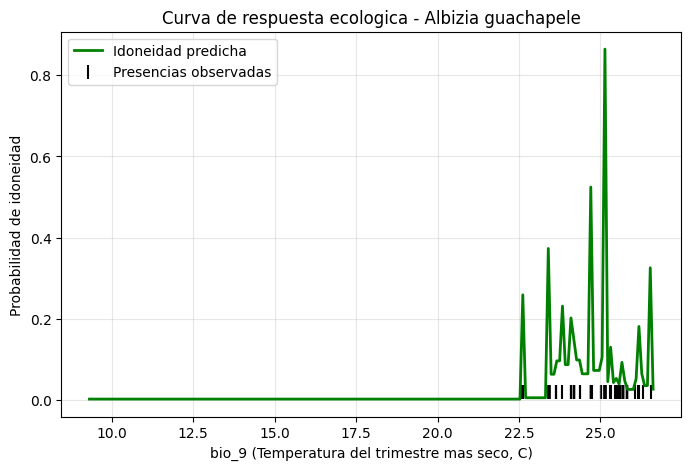

In [0]:
import numpy as np
import matplotlib.pyplot as plt

mejor_modelo = modelos['Gradient Boosting']

rango_bio9 = np.linspace(gold['bio_9'].min(), gold['bio_9'].max(), 200).reshape(-1, 1)
probabilidades = mejor_modelo.predict_proba(rango_bio9)[:, 1]

plt.figure(figsize=(8, 5))
plt.plot(rango_bio9, probabilidades, color='green', linewidth=2, label='Idoneidad predicha')
plt.scatter(gold.loc[gold['presencia'] == 1, 'bio_9'], [0.02] * int(gold['presencia'].sum()),
            marker='|', color='black', s=100, label='Presencias observadas')
plt.xlabel('bio_9 (Temperatura del trimestre mas seco, C)')
plt.ylabel('Probabilidad de idoneidad')
plt.title('Curva de respuesta ecologica - Albizia guachapele')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [0]:
#otra prueba

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# GLM cuadratico (bio_9 + bio_9^2), el estandar en modelado de nicho
glm_cuadratico = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LogisticRegression(class_weight='balanced')
)

# Gradient Boosting regularizado (menos complejo, para evitar sobreajuste)
gb_regularizado = GradientBoostingClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.05,
    min_samples_leaf=15,
    random_state=42
)

modelos_v2 = {
    'GLM cuadratico': glm_cuadratico,
    'Gradient Boosting (regularizado)': gb_regularizado,
    'Random Forest (regularizado)': RandomForestClassifier(
        n_estimators=100, max_depth=4, min_samples_leaf=10,
        class_weight='balanced', random_state=42
    ),
}

resultados_v2 = []
for nombre, modelo in modelos_v2.items():
    cv_auc = cross_val_score(modelo, X_train, y_train, cv=5, scoring='roc_auc').mean()
    modelo.fit(X_train, y_train)
    y_pred_proba = modelo.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_pred_proba)
    resultados_v2.append({'modelo': nombre, 'cv_auc_train': cv_auc, 'test_auc': test_auc})

print(pd.DataFrame(resultados_v2).sort_values('test_auc', ascending=False))

                             modelo  cv_auc_train  test_auc
1  Gradient Boosting (regularizado)      0.880713  0.955412
2      Random Forest (regularizado)      0.902953  0.939483
0                    GLM cuadratico      0.782937  0.788656


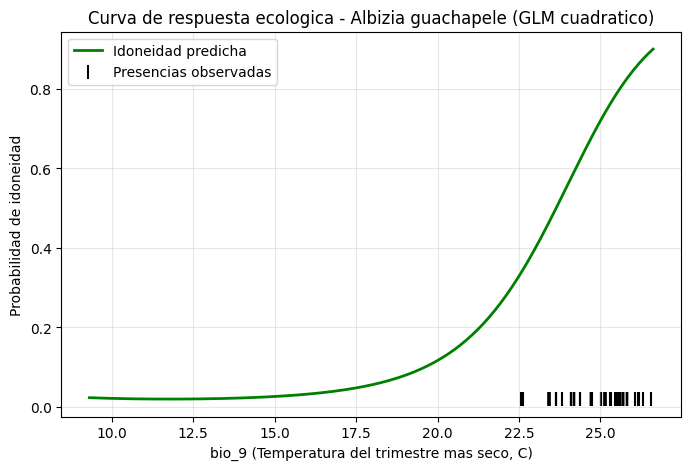

In [0]:
import numpy as np
import matplotlib.pyplot as plt

mejor_modelo = modelos_v2['GLM cuadratico']

rango_bio9 = np.linspace(gold['bio_9'].min(), gold['bio_9'].max(), 200).reshape(-1, 1)
probabilidades = mejor_modelo.predict_proba(rango_bio9)[:, 1]

plt.figure(figsize=(8, 5))
plt.plot(rango_bio9, probabilidades, color='green', linewidth=2, label='Idoneidad predicha')
plt.scatter(gold.loc[gold['presencia'] == 1, 'bio_9'], [0.02] * int(gold['presencia'].sum()),
            marker='|', color='black', s=100, label='Presencias observadas')
plt.xlabel('bio_9 (Temperatura del trimestre mas seco, C)')
plt.ylabel('Probabilidad de idoneidad')
plt.title('Curva de respuesta ecologica - Albizia guachapele (GLM cuadratico)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

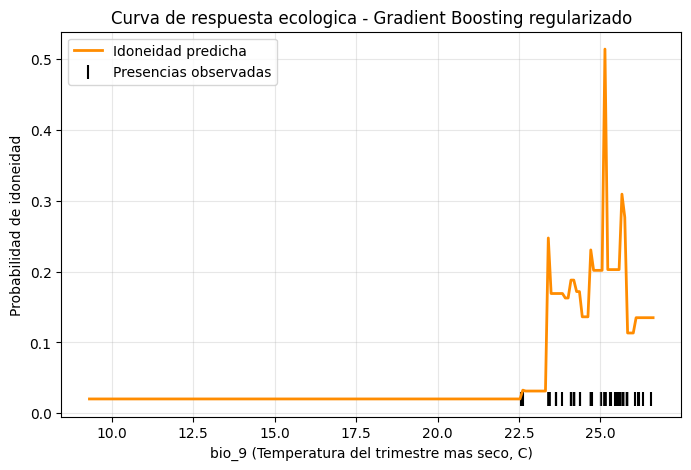

In [0]:
mejor_modelo = modelos_v2['Gradient Boosting (regularizado)']

rango_bio9 = np.linspace(gold['bio_9'].min(), gold['bio_9'].max(), 200).reshape(-1, 1)
probabilidades = mejor_modelo.predict_proba(rango_bio9)[:, 1]

plt.figure(figsize=(8, 5))
plt.plot(rango_bio9, probabilidades, color='darkorange', linewidth=2, label='Idoneidad predicha')
plt.scatter(gold.loc[gold['presencia'] == 1, 'bio_9'], [0.02] * int(gold['presencia'].sum()),
            marker='|', color='black', s=100, label='Presencias observadas')
plt.xlabel('bio_9 (Temperatura del trimestre mas seco, C)')
plt.ylabel('Probabilidad de idoneidad')
plt.title('Curva de respuesta ecologica - Gradient Boosting regularizado')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [0]:
%pip install elapid

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from elapid import MaxentModel

maxent = MaxentModel(feature_types=['linear', 'quadratic'])

cv_auc_maxent = cross_val_score(maxent, X_train, y_train, cv=5, scoring='roc_auc').mean()
maxent.fit(X_train, y_train)
y_pred_proba_maxent = maxent.predict_proba(X_test)[:, 1]
test_auc_maxent = roc_auc_score(y_test, y_pred_proba_maxent)

resultados_v3 = resultados_v2 + [{
    'modelo': 'MaxEnt (elapid, linear+quadratic)',
    'cv_auc_train': cv_auc_maxent,
    'test_auc': test_auc_maxent
}]

tabla_final = pd.DataFrame(resultados_v3).sort_values('test_auc', ascending=False)
print(tabla_final)

                              modelo  cv_auc_train  test_auc
1   Gradient Boosting (regularizado)      0.880713  0.955412
2       Random Forest (regularizado)      0.902953  0.939483
3  MaxEnt (elapid, linear+quadratic)      0.782874  0.789989
0                     GLM cuadratico      0.782937  0.788656


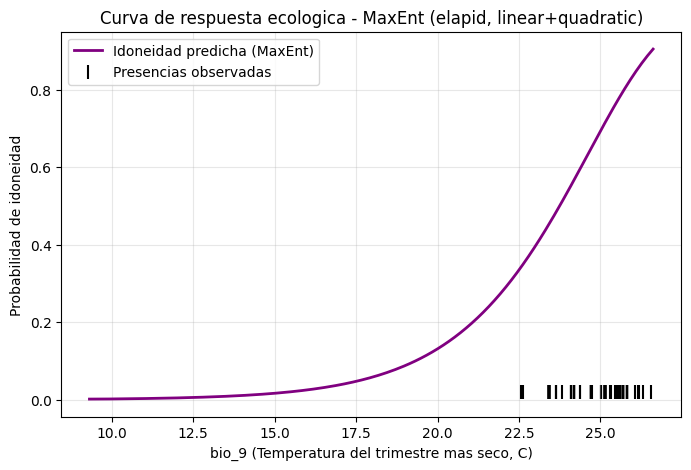

In [0]:
rango_bio9 = np.linspace(gold['bio_9'].min(), gold['bio_9'].max(), 200).reshape(-1, 1)
probabilidades_maxent = maxent.predict_proba(rango_bio9)[:, 1]

plt.figure(figsize=(8, 5))
plt.plot(rango_bio9, probabilidades_maxent, color='purple', linewidth=2, label='Idoneidad predicha (MaxEnt)')
plt.scatter(gold.loc[gold['presencia'] == 1, 'bio_9'], [0.02] * int(gold['presencia'].sum()),
            marker='|', color='black', s=100, label='Presencias observadas')
plt.xlabel('bio_9 (Temperatura del trimestre mas seco, C)')
plt.ylabel('Probabilidad de idoneidad')
plt.title('Curva de respuesta ecologica - MaxEnt (elapid, linear+quadratic)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [0]:
spark.sql('CREATE SCHEMA IF NOT EXISTS especies_nativas.models')

import numpy as np

X_full = np.vstack([X_train, X_test])
y_full = np.concatenate([y_train, y_test])

modelo_final = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LogisticRegression(class_weight='balanced')
)
modelo_final.fit(X_full, y_full)

print('Modelo final reentrenado con', len(X_full), 'registros')

Modelo final reentrenado con 1364 registros


In [0]:
"""import mlflow
from mlflow.models.signature import infer_signature

mlflow.set_registry_uri('databricks-uc')

signature = infer_signature(X_full, modelo_final.predict_proba(X_full))

with mlflow.start_run(run_name='glm_cuadratico_albizia_bio9'):
    mlflow.log_param('modelo', 'GLM cuadratico (bio_9 + bio_9^2)')
    mlflow.log_metric('cv_auc_train', 0.782937)
    mlflow.log_metric('test_auc', 0.789589)
    mlflow.sklearn.log_model(
        modelo_final,
        artifact_path='model',
        signature=signature,
        input_example=X_full[:5],
        registered_model_name='especies_nativas.models.albizia_guachapele_bio9'
    )

print('Modelo registrado en Unity Catalog correctamente') """



2026/09/13 23:10:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-28cdcc52-d3e9.cloud.databricks.com/ml/experiments/571143522772306/models/m-1c5598a3b3aa4feaa7397969af52b3b6?o=7474651130639660
Successfully registered model 'especies_nativas.models.albizia_guachapele_bio9'.


Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '1' of model 'especies_nativas.models.albizia_guachapele_bio9': https://dbc-28cdcc52-d3e9.cloud.databricks.com/explore/data/models/especies_nativas/models/albizia_guachapele_bio9/version/1?o=7474651130639660


Modelo registrado en Unity Catalog correctamente


In [0]:
import mlflow
import mlflow.pyfunc
from mlflow.models.signature import infer_signature

mlflow.set_registry_uri('databricks-uc')

class ProbabilityWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, sklearn_model):
        self.sklearn_model = sklearn_model

    def predict(self, context, model_input):
        proba = self.sklearn_model.predict_proba(model_input)[:, 1]
        return proba

wrapped_model = ProbabilityWrapper(modelo_final)

salida_ejemplo = modelo_final.predict_proba(X_full)[:, 1]
signature = infer_signature(X_full, salida_ejemplo)

with mlflow.start_run(run_name='glm_cuadratico_albizia_bio9_proba'):
    mlflow.log_param('modelo', 'GLM cuadratico (bio_9 + bio_9^2) - output probabilidad')
    mlflow.pyfunc.log_model(
        python_model=wrapped_model,
        artifact_path='model',
        signature=signature,
        input_example=X_full[:5],
        registered_model_name='especies_nativas.models.albizia_guachapele_bio9'
    )

print('Version 2 registrada correctamente (con output de probabilidad)')

/databricks/python/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/09/13 23:43:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-28cdcc52-d3e9.cloud.databricks.com/ml/experiments/571143522772306/models/m-5055c1c6b9ff4843a920152bbdb4077e?o=7474651130639660
2026/09/13 23:43:01 INFO mlflow.pyfunc: Validating input example against model signature
Registered model 'especies_nativas.models.albizia_guachapele_bio9' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '3' of model 'especies_nativas.models.albizia_guachapele_bio9': https://dbc-28cdcc52-d3e9.cloud.databricks.com/explore/data/models/especies_nativas/models/albizia_guachapele_bio9/version/3?o=7474651130639660


Version 2 registrada correctamente (con output de probabilidad)


In [0]:
import requests

HOST = "https://dbc-28cdcc52-d3e9.cloud.databricks.com"
ENDPOINT_NAME = "albizia-guachapele-bio9"

ctx = dbutils.notebook.entry_point.getDbutils().notebook().getContext()
token = ctx.apiToken().get()

resp = requests.post(
    f"{HOST}/serving-endpoints/{ENDPOINT_NAME}/invocations",
    headers={"Authorization": f"Bearer {token}", "Content-Type": "application/json"},
    json={"inputs": [[25.6]]}
)
print(resp.status_code)
print(resp.json())

200
{'predictions': [0.8009267449378967]}


/databricks/python/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-5772906553735868>, line 11
      8         proba = self.sklearn_model.predict_proba(model_input)[:, 1]
      9         return proba
---> 11 wrapped_model = ProbabilityWrapper(modelo_final)
     13 with mlflow.start_run(run_name='glm_cuadratico_albizia_bio9_proba'):
     14     mlflow.log_param('modelo', 'GLM cuadratico (bio_9 + bio_9^2) - output probabilidad')

NameError: name 'modelo_final' is not defined